In [1]:
# Install library
!pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
# Load dataset
dataset = fetch_ucirepo(id=17)

X = dataset.data.features
y = dataset.data.targets

# Combine dataset
df = pd.concat([X, y], axis=1)

print("\n===== DATASET INFO =====")
print(df.info())


===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-nul

In [4]:
print("\n===== DATASET SUMMARY =====")
print(df.describe())


===== DATASET SUMMARY =====
          radius1    texture1  perimeter1        area1  smoothness1  \
count  569.000000  569.000000  569.000000   569.000000   569.000000   
mean    14.127292   19.289649   91.969033   654.889104     0.096360   
std      3.524049    4.301036   24.298981   351.914129     0.014064   
min      6.981000    9.710000   43.790000   143.500000     0.052630   
25%     11.700000   16.170000   75.170000   420.300000     0.086370   
50%     13.370000   18.840000   86.240000   551.100000     0.095870   
75%     15.780000   21.800000  104.100000   782.700000     0.105300   
max     28.110000   39.280000  188.500000  2501.000000     0.163400   

       compactness1  concavity1  concave_points1   symmetry1  \
count    569.000000  569.000000       569.000000  569.000000   
mean       0.104341    0.088799         0.048919    0.181162   
std        0.052813    0.079720         0.038803    0.027414   
min        0.019380    0.000000         0.000000    0.106000   
25%        

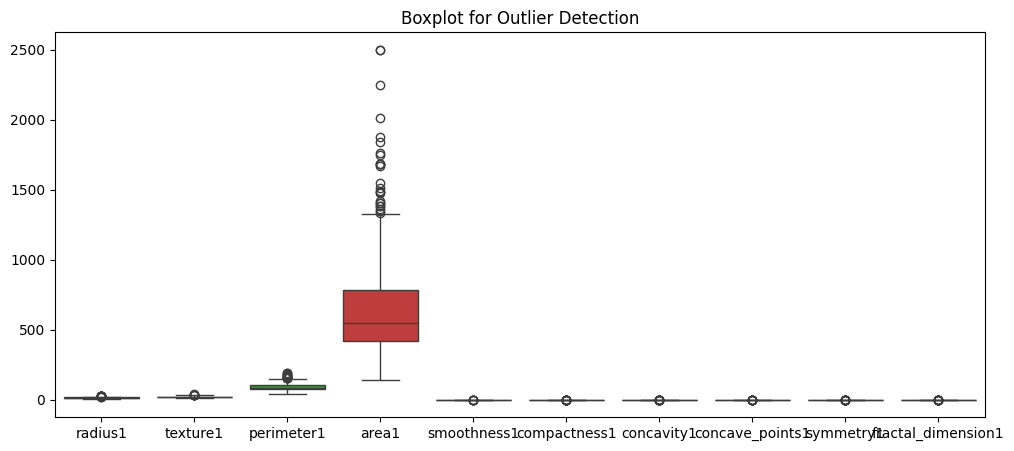

In [6]:
# Boxplot (first 10 numeric columns)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,5))
sns.boxplot(data=numeric_df.iloc[:, :10])
plt.title("Boxplot for Outlier Detection")
plt.show()

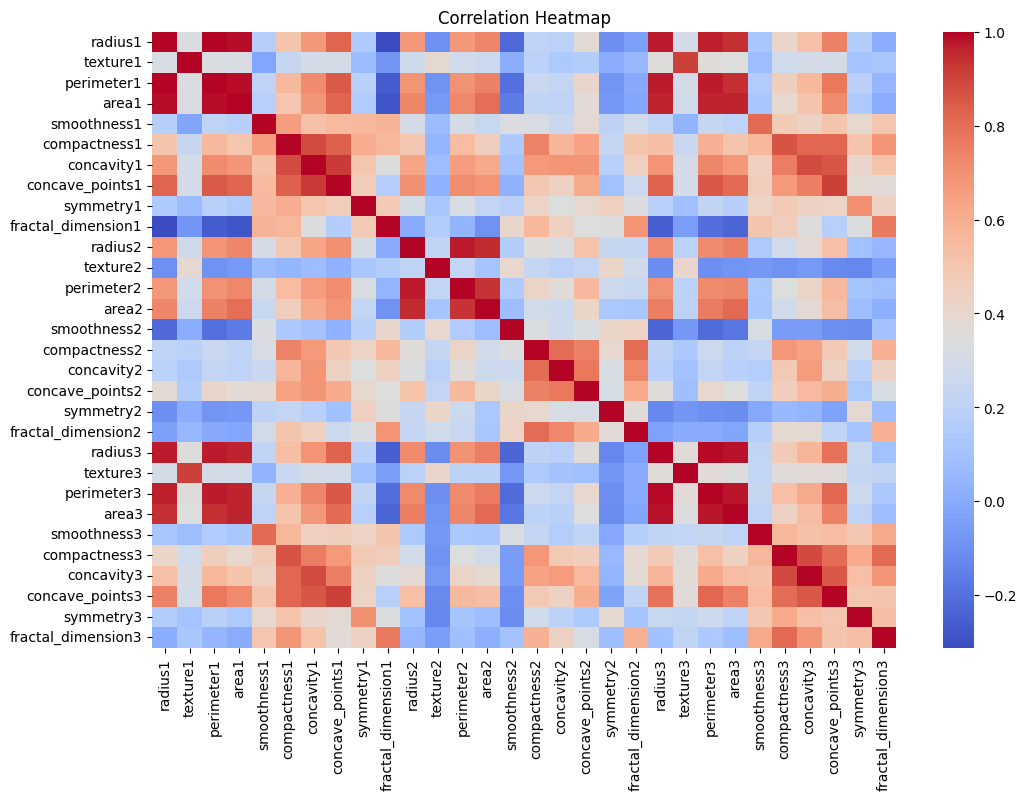

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Rename columns
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Remove duplicates
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicate Rows: 0


In [9]:
# Drop irrelevant column if exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

print("\nData Types:\n", df.dtypes)


Data Types:
 radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
diagnosis              object
dtype: object


In [10]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values (mean for numeric)
df = df.fillna(df.mean(numeric_only=True))

# Select numeric columns again
numeric_df = df.select_dtypes(include=[np.number])


Missing Values:
 radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
diagnosis             0
dtype: int64


In [11]:
# ---- OUTLIER HANDLING USING CAPPING (BEST METHOD) ----
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

print("\nOutliers handled using capping method.")


Outliers handled using capping method.


In [12]:
# Encode target column (diagnosis or last column)
target_col = df.columns[-1]

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

In [13]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

In [14]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [16]:
# Final dataset
final_df = pd.concat([X_scaled, y], axis=1)

print("\n===== FINAL TRANSFORMED DATA =====")
print(final_df.head())


===== FINAL TRANSFORMED DATA =====
    radius1  texture1  perimeter1     area1  smoothness1  compactness1  \
0  1.176800 -2.121200    1.357375  1.184085     1.618861      2.541404   
1  1.949929 -0.354875    1.795991  2.249396    -0.842995     -0.498189   
2  1.686226  0.476899    1.670052  1.846217     0.975239      1.148680   
3 -0.791983  0.268955   -0.606410 -0.831485     2.737521      2.541404   
4  1.866023 -1.174698    1.891531  2.154338     0.295047      0.599453   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0    2.647422         2.620973   2.348535            2.511708  ... -1.375159   
1   -0.000497         0.574944   0.017882           -0.925449  ... -0.370048   
2    1.496076         2.110330   1.004666           -0.407692  ... -0.019582   
3    2.091997         1.506601   2.521318            2.517947  ...  0.140773   
4    1.504202         1.482665   0.006363           -0.588595  ... -1.484267   

   perimeter3     area3  smoothness3  